**Digital Planimetry**

In [ ]:
from PIL import Image

# Open the image
img = Image.open('/content/drive/MyDrive/Treehouse/leaf_area/APCA_11.tif')

# Show the image (opens in your default OS image viewer)
img.show()

# Print basic metadata
print(f"Format: {img.format}")
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")

Format: TIFF
Size: (2479, 3507)
Mode: RGB


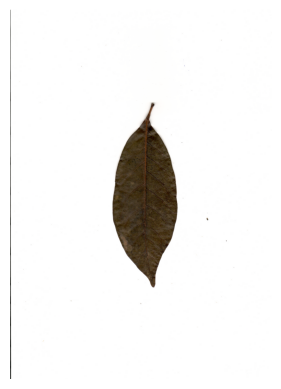

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Read the image
img = mpimg.imread('/content/drive/MyDrive/Treehouse/leaf_area/APCA_11.tif')

# Plot the image
plt.imshow(img)
plt.axis('off') # Optional: turn off axis numbers
plt.show()

Leaf Area: 46.90 cm²


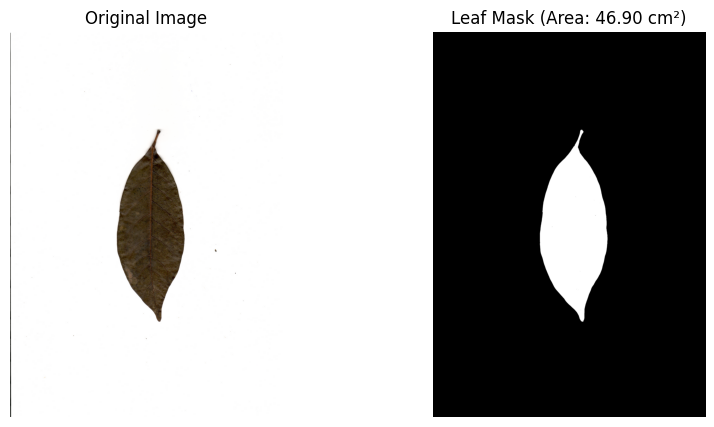

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def calculate_leaf_area(image_path, dpi=300):
    # 1. Load the image
    # Read as RGB
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Reshape image for K-Means
    # Flatten the image into a list of pixels (Height * Width, 3)
    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # 3. K-Means Classification (Parametric Unsupervised)
    # We ask for 2 clusters: Leaf and Background
    k = 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    # 4. Identify which cluster is the leaf
    # The background is usually brighter (closer to 255, 255, 255)
    centers = kmeans.cluster_centers_
    # Calculate the mean intensity of each center
    intensities = np.mean(centers, axis=1)
    # The cluster with the lower intensity is the leaf
    leaf_cluster_label = np.argmin(intensities)

    # 5. Create Binary Mask (1 for leaf, 0 for background)
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    # Reshape mask back to original image dimensions
    mask_img = mask.reshape(img.shape[:2])

    # --- NOISE REMOVAL STEP ---
    # Scans often have black borders or dust. We keep only the largest object (the leaf).
    # This removes the vertical line on the left of your scan if it's disconnected.
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(mask_img, connectivity=8)

    # Identify the largest component that is NOT the background (label 0)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    # Update mask to only include the largest leaf object
    final_mask = np.zeros_like(mask_img)
    final_mask[labels_im == largest_label] = 1

    # 6. Calculate Area
    pixel_count = np.sum(final_mask)

    # Conversion factors
    # 1 inch = 2.54 cm
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2  # Area of one pixel in cm^2

    total_area_cm2 = pixel_count * area_per_pixel

    return img, final_mask, total_area_cm2

# --- RUNNING THE FUNCTION ---
image_path = '/content/drive/MyDrive/Treehouse/leaf_area/APCA_11.tif' # Using the file you uploaded
try:
    original, mask, area = calculate_leaf_area(image_path)

    print(f"Leaf Area: {area:.2f} cm²")

    # Plot the results to verify classification
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title(f"Leaf Mask (Area: {area:.2f} cm²)")
    ax[1].axis('off')

    plt.show()

except Exception as e:
    print(f"Error processing image: {e}")

Leaf Area: 46.90 cm^2


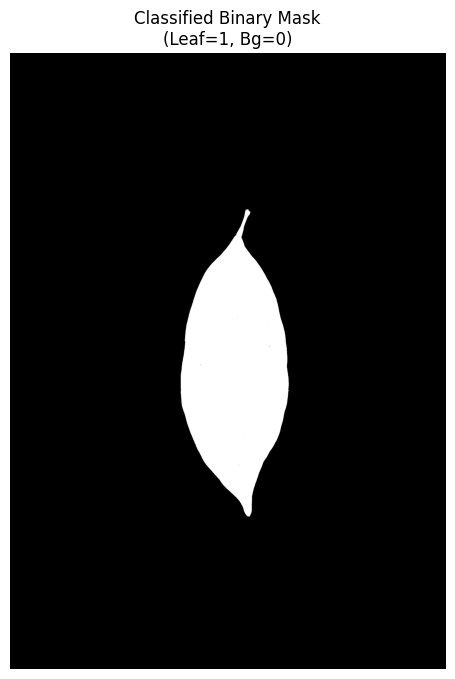

Saved binary_mask.png


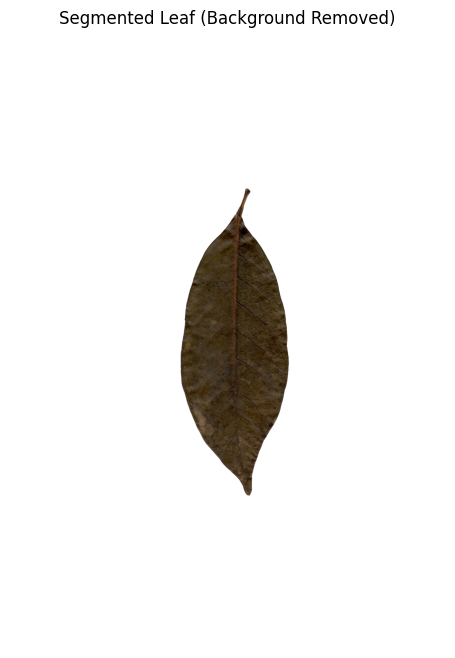

Saved segmented_leaf.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def process_and_plot_leaf(image_path, dpi=300):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image. Check the path.")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Reshape for K-Means
    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # 3. K-Means Classification
    k = 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    # 4. Identify leaf cluster (darker one)
    centers = kmeans.cluster_centers_
    intensities = np.mean(centers, axis=1)
    leaf_cluster_label = np.argmin(intensities)

    # 5. Create Mask
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    mask_img = mask.reshape(img.shape[:2])

    # 6. Noise Removal (Keep largest connected component)
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(mask_img, connectivity=8)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    final_mask = np.zeros_like(mask_img)
    final_mask[labels_im == largest_label] = 1

    # 7. Calculate Area
    pixel_count = np.sum(final_mask)
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2
    total_area_cm2 = pixel_count * area_per_pixel

    print(f"Leaf Area: {total_area_cm2:.2f} cm^2")

    # 8. Create Segmented Image (Apply mask to original)
    # Create a white background image
    white_bg = np.ones_like(img) * 255
    # Where mask is 1, use original image. Where mask is 0, use white background.
    segmented_img = np.where(final_mask[..., None] == 1, img, white_bg)

    # 9. Plotting - SEPARATE PLOTS

    # Plot 1: Binary Mask (The "Classified" 0/1 representation)
    plt.figure(figsize=(6, 8))
    plt.imshow(final_mask, cmap='gray')
    plt.title(f"Classified Binary Mask\n(Leaf=1, Bg=0)")
    plt.axis('off')
    #plt.savefig('binary_mask.png', bbox_inches='tight')
    plt.show()
    print("Saved binary_mask.png")

    # Plot 2: Segmented Leaf (Visual confirmation)
    plt.figure(figsize=(6, 8))
    plt.imshow(segmented_img)
    plt.title("Segmented Leaf (Background Removed)")
    plt.axis('off')
    #plt.savefig('segmented_leaf.png', bbox_inches='tight')
    plt.show()
    print("Saved segmented_leaf.png")

# Run the function
process_and_plot_leaf('/content/drive/MyDrive/Treehouse/leaf_area/APCA_11.tif')

Leaf Area: 32.91 cm²


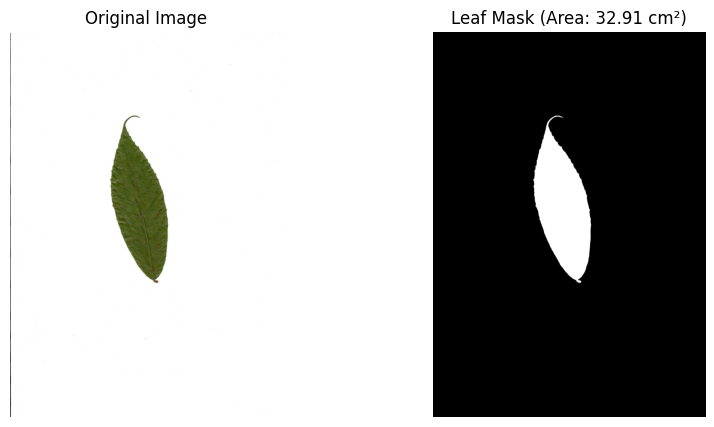

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def calculate_leaf_area(image_path, dpi=300):
    # 1. Load the image
    # Read as RGB
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Reshape image for K-Means
    # Flatten the image into a list of pixels (Height * Width, 3)
    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # 3. K-Means Classification (Parametric Unsupervised)
    # We ask for 2 clusters: Leaf and Background
    k = 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    # 4. Identify which cluster is the leaf
    # The background is usually brighter (closer to 255, 255, 255)
    centers = kmeans.cluster_centers_
    # Calculate the mean intensity of each center
    intensities = np.mean(centers, axis=1)
    # The cluster with the lower intensity is the leaf
    leaf_cluster_label = np.argmin(intensities)

    # 5. Create Binary Mask (1 for leaf, 0 for background)
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    # Reshape mask back to original image dimensions
    mask_img = mask.reshape(img.shape[:2])

    # --- NOISE REMOVAL STEP ---
    # Scans often have black borders or dust. We keep only the largest object (the leaf).
    # This removes the vertical line on the left of your scan if it's disconnected.
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(mask_img, connectivity=8)

    # Identify the largest component that is NOT the background (label 0)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    # Update mask to only include the largest leaf object
    final_mask = np.zeros_like(mask_img)
    final_mask[labels_im == largest_label] = 1

    # 6. Calculate Area
    pixel_count = np.sum(final_mask)

    # Conversion factors
    # 1 inch = 2.54 cm
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2  # Area of one pixel in cm^2

    total_area_cm2 = pixel_count * area_per_pixel

    return img, final_mask, total_area_cm2

# --- RUNNING THE FUNCTION ---
image_path = '/content/drive/MyDrive/Treehouse/leaf_area/ANTO_291.tif' # Using the file you uploaded
try:
    original, mask, area = calculate_leaf_area(image_path)

    print(f"Leaf Area: {area:.2f} cm²")

    # Plot the results to verify classification
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title(f"Leaf Mask (Area: {area:.2f} cm²)")
    ax[1].axis('off')

    plt.show()

except Exception as e:
    print(f"Error processing image: {e}")

Leaf Area: 34.41 cm²


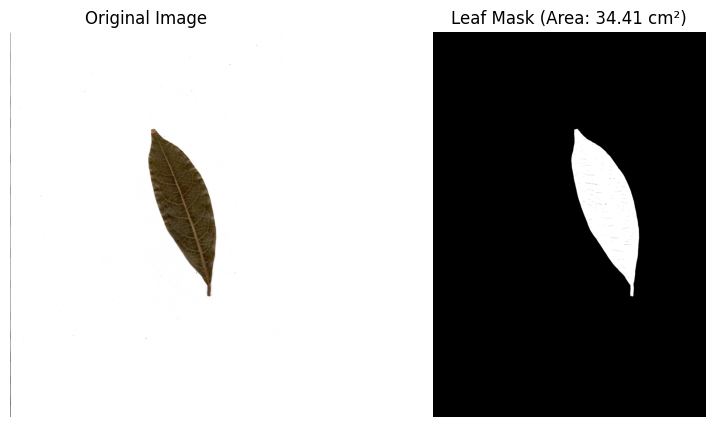

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def calculate_leaf_area(image_path, dpi=300):
    # 1. Load the image
    # Read as RGB
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Reshape image for K-Means
    # Flatten the image into a list of pixels (Height * Width, 3)
    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # 3. K-Means Classification (Parametric Unsupervised)
    # We ask for 2 clusters: Leaf and Background
    k = 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    # 4. Identify which cluster is the leaf
    # The background is usually brighter (closer to 255, 255, 255)
    centers = kmeans.cluster_centers_
    # Calculate the mean intensity of each center
    intensities = np.mean(centers, axis=1)
    # The cluster with the lower intensity is the leaf
    leaf_cluster_label = np.argmin(intensities)

    # 5. Create Binary Mask (1 for leaf, 0 for background)
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    # Reshape mask back to original image dimensions
    mask_img = mask.reshape(img.shape[:2])

    # --- NOISE REMOVAL STEP ---
    # Scans often have black borders or dust. We keep only the largest object (the leaf).
    # This removes the vertical line on the left of your scan if it's disconnected.
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(mask_img, connectivity=8)

    # Identify the largest component that is NOT the background (label 0)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    # Update mask to only include the largest leaf object
    final_mask = np.zeros_like(mask_img)
    final_mask[labels_im == largest_label] = 1

    # 6. Calculate Area
    pixel_count = np.sum(final_mask)

    # Conversion factors
    # 1 inch = 2.54 cm
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2  # Area of one pixel in cm^2

    total_area_cm2 = pixel_count * area_per_pixel

    return img, final_mask, total_area_cm2

# --- RUNNING THE FUNCTION ---
image_path = '/content/drive/MyDrive/Treehouse/leaf_area/BEDA_51.tif' # Using the file you uploaded
try:
    original, mask, area = calculate_leaf_area(image_path)

    print(f"Leaf Area: {area:.2f} cm²")

    # Plot the results to verify classification
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title(f"Leaf Mask (Area: {area:.2f} cm²)")
    ax[1].axis('off')

    plt.show()

except Exception as e:
    print(f"Error processing image: {e}")

the leaf veins and shiny textures are light-colored

Leaf Area: 34.53 cm²


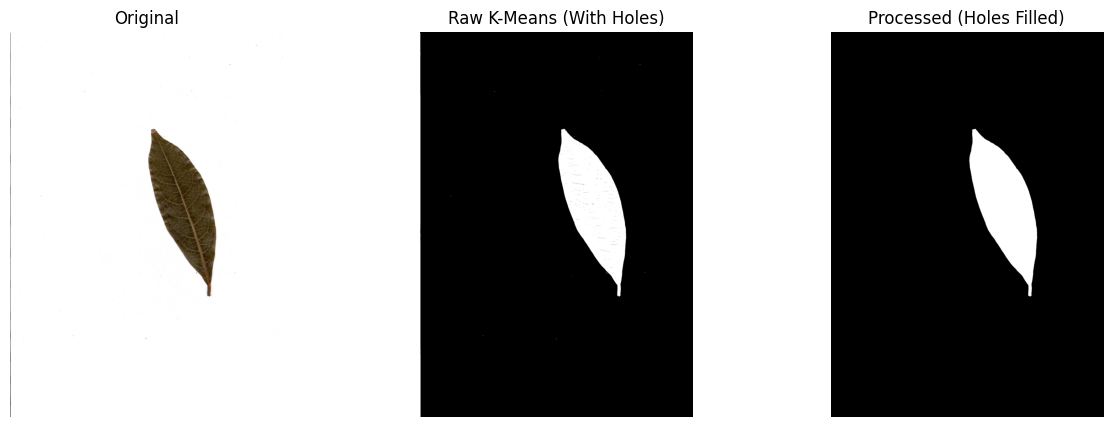

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def calculate_leaf_area_robust(image_path, dpi=300):
    # 1. Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. K-Means (Same as before)
    pixel_values = img_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    centers = kmeans.cluster_centers_
    # Leaf is the darker cluster
    leaf_cluster_label = np.argmin(np.mean(centers, axis=1))

    # Initial Mask (Noisy)
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    mask = mask.reshape(img_rgb.shape[:2])

    # --- NEW: STEP 3 - MORPHOLOGICAL CLOSING ---
    # This fills small holes (veins/noise)
    # A (5,5) kernel is usually enough for 300 DPI
    kernel = np.ones((5,5), np.uint8)
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # --- NEW: STEP 4 - FILL HOLES VIA CONTOURS ---
    # Find contours
    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank mask
    mask_filled = np.zeros_like(mask)

    if contours:
        # Find the largest contour (the leaf)
        largest_contour = max(contours, key=cv2.contourArea)

        # Draw the contour filled (thickness=-1) on the new mask
        cv2.drawContours(mask_filled, [largest_contour], -1, 1, thickness=cv2.FILLED)

    # 5. Calculate Area
    pixel_count = np.sum(mask_filled)
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2
    total_area_cm2 = pixel_count * area_per_pixel

    return img_rgb, mask, mask_filled, total_area_cm2

# --- Run on your image ---
# Replace with your actual file path
image_path = '/content/drive/MyDrive/Treehouse/leaf_area/BEDA_51.tif'

try:
    original, noisy_mask, final_mask, area = calculate_leaf_area_robust(image_path)
    print(f"Leaf Area: {area:.2f} cm²")

    # Visualization
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(original)
    ax[0].set_title("Original")
    ax[0].axis('off')

    ax[1].imshow(noisy_mask, cmap='gray')
    ax[1].set_title("Raw K-Means (With Holes)")
    ax[1].axis('off')

    ax[2].imshow(final_mask, cmap='gray')
    ax[2].set_title("Processed (Holes Filled)")
    ax[2].axis('off')

    plt.show()

except Exception as e:
    print(f"Error: {e}")

Phase A: **Dilation** (Expand)
Imagine sliding that 5x5 square over every pixel of your image.

The Rule: If any part of the white leaf touches the square, the center of the square turns white.

The Effect: This makes the leaf slightly "fatter." Crucially, if there is a small black gap (like a vein) between two white areas, the "fatness" from both sides meets in the middle and bridges the gap.

Phase B: **Erosion** (Shrink)
Now, we slide the square over the new dilated image.

The Rule: If any part of the black background touches the square, the center turns black.

The Effect: This shaves away the extra "fat" we just added, returning the leaf to its original size.

The Magic: The "bridges" we built over the veins during Dilation are now solid white. Because they are solid, the Erosion step doesn't remove them. The gap is permanently sealed.

### 1. Dilation (The "Fill" Step)

**The Vibe:** *Generous* (Expanding White)

**The Logic:** "Any is Enough"

When the **$5 \times 5$** square slides over a pixel, the computer asks:
> *"Is even **ONE** of the 25 pixels underneath this square white?"*

* **YES** (If at least one pixel is white) $\rightarrow$ The center pixel turns **White (1)**.
* **NO** (Only if ALL pixels are black) $\rightarrow$ The center pixel stays **Black (0)**.

---

### 2. Erosion (The "Cut" Step)

**The Vibe:** *Strict* (Shrinking White)

**The Logic:** "All or Nothing"

When the **$5 \times 5$** square slides over a pixel, the computer asks:
> *"Are **ALL** 25 pixels underneath this square white?"*

* **YES** (Only if every single pixel is white) $\rightarrow$ The center pixel stays **White (1)**.
* **NO** (If even one pixel is black) $\rightarrow$ The center pixel turns **Black (0)**.

Even after Closing, you might have a large "island" of black inside the leaf (e.g., a really shiny spot). The Morphological Closing only fixes small gaps. This step fixes the rest.


cv2.drawContours(mask_filled, [largest_contour], -1, 1, thickness=cv2.FILLED)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

def process_and_export_stages(image_path, dpi=300):
    # Get the filename without extension for saving outputs (e.g., "BEDA_51")
    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # --- STAGE 1: LOAD IMAGE ---
    print(f"Processing {base_name}...")
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image.")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Save Stage 1: Original
    # We save using matplotlib to add the title/text cleanly, or cv2 for raw pixels.
    # Here we use plt to add your specific labels.
    save_high_res(img_rgb, f"{base_name}_01_Original", "Scanned Leaf Image (300 DPI)")

    # --- STAGE 2: K-MEANS CLASSIFICATION ---
    pixel_values = img_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    centers = kmeans.cluster_centers_
    leaf_cluster_label = np.argmin(np.mean(centers, axis=1))

    # Create raw mask
    mask = (labels == leaf_cluster_label).astype(np.uint8)
    mask = mask.reshape(img_rgb.shape[:2])

    # Save Stage 2: Raw K-Means
    save_high_res(mask, f"{base_name}_02_KMeans", "K-means Classified Image (Raw)", cmap='gray')

    # --- STAGE 3: REFINEMENT (KERNEL + CONTOURS) ---
    # Morphological Closing
    kernel = np.ones((5,5), np.uint8)
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Fill Holes
    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_filled = np.zeros_like(mask)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_filled, [largest_contour], -1, 1, thickness=cv2.FILLED)

    # Save Stage 3: Refined
    save_high_res(mask_filled, f"{base_name}_03_Refined", "Refinement using Kernel (Closed & Filled)", cmap='gray')

    # --- STAGE 4: CALCULATION & FINAL OUTPUT ---
    pixel_count = np.sum(mask_filled)
    pixels_per_cm = dpi / 2.54
    area_per_pixel = (1 / pixels_per_cm) ** 2
    total_area_cm2 = pixel_count * area_per_pixel

    # Create a visual result where we overlay the mask on the leaf
    # (Optional visual flair for the final slide)
    result_overlay = img_rgb.copy()
    # Darken background to highlight leaf
    result_overlay[mask_filled == 0] = result_overlay[mask_filled == 0] // 3

    # Save Stage 4: Final Result with Text
    save_high_res(result_overlay, f"{base_name}_04_Final", f"Leaf Area: {total_area_cm2:.2f} cm^2")

    print(f"Done! Saved 4 images starting with '{base_name}_...'")
    return total_area_cm2

def save_high_res(img_data, filename, title, cmap=None):
    """
    Helper function to save images with titles at 900 DPI.
    """
    plt.figure(figsize=(10, 12)) # Vertical portrait aspect ratio

    if cmap:
        plt.imshow(img_data, cmap=cmap)
    else:
        plt.imshow(img_data)

    plt.title(title, fontsize=15, pad=20)
    plt.axis('off')

    # Save at 900 DPI
    plt.savefig(f"{filename}.png", dpi=900, bbox_inches='tight')
    plt.close() # Close memory to prevent crashing loops

# --- RUN THE SCRIPT ---
# Update this path to your file
image_path = '/content/drive/MyDrive/Treehouse/leaf_area/BEDA_51.tif'

try:
    area = process_and_export_stages(image_path)
    print(f"Calculated Area: {area:.2f}")
except Exception as e:
    print(f"Error: {e}")

Processing BEDA_51...
Done! Saved 4 images starting with 'BEDA_51_...'
Calculated Area: 34.53
